In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.ensemble import VotingClassifier, VotingRegressor, BaggingRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, f1_score, accuracy_score, log_loss, r2_score
from sklearn.tree import DecisionTreeClassifier

In [14]:
sonar=pd.read_csv('Sonar.csv')
le=LabelEncoder()
y=le.fit_transform(sonar['Class'])
X=sonar.drop('Class',axis=1)

In [15]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=25,stratify=y)

In [16]:
features = [2,3,4,5,6,7,8,9,10]
scores = []
for f in features:
    rf = RandomForestClassifier(random_state=25, max_features=f)
    rf.fit(X_train,y_train)
    y_pred = rf.predict(X_test)
    scores.append([f,accuracy_score(y_test,y_pred)])
df_scores = pd.DataFrame(scores,columns=['Feature','score'])
df_scores.sort_values('score', ascending=False)

,Feature,score
3,5,0.761905
2,4,0.746032
1,3,0.746032
8,10,0.730159
4,6,0.730159
0,2,0.714286
5,7,0.714286
6,8,0.714286
7,9,0.698413


In [17]:
features = [2,3,4,5,6,7,8,9,10]
scores = []
for f in features:
    rf = RandomForestRegressor(random_state=25, max_features=f)
    rf.fit(X_train,y_train)
    y_pred = rf.predict(X_test)
    scores.append([f,r2_score(y_test,y_pred)])
df_scores = pd.DataFrame(scores,columns=['Feature','score'])
df_scores.sort_values('score', ascending=False)

,Feature,score
3,5,0.387354
6,8,0.372102
8,10,0.344570
5,7,0.335733
0,2,0.330884
2,4,0.328539
4,6,0.316910
7,9,0.304943
1,3,0.301390


<function matplotlib.pyplot.show(close=None, block=None)>

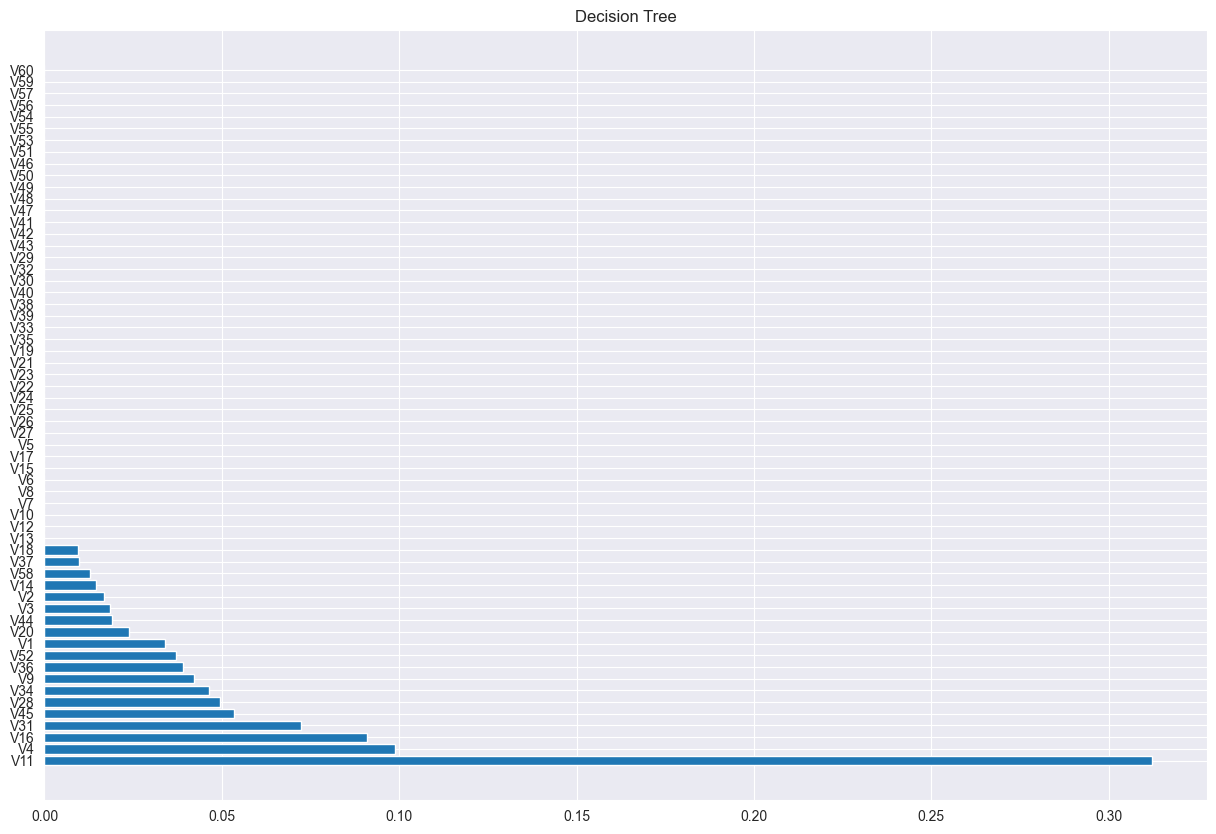

In [23]:
dtc = DecisionTreeClassifier(random_state=25)
dtc.fit(X,y)
df_imp = pd.DataFrame({'features':list(X.columns), 'importance':dtc.feature_importances_})
df_imp.sort_values('importance', ascending=False, inplace=True)
plt.figure(figsize=(15,10))
plt.barh(df_imp['features'], df_imp['importance'])
plt.title('Decision Tree')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

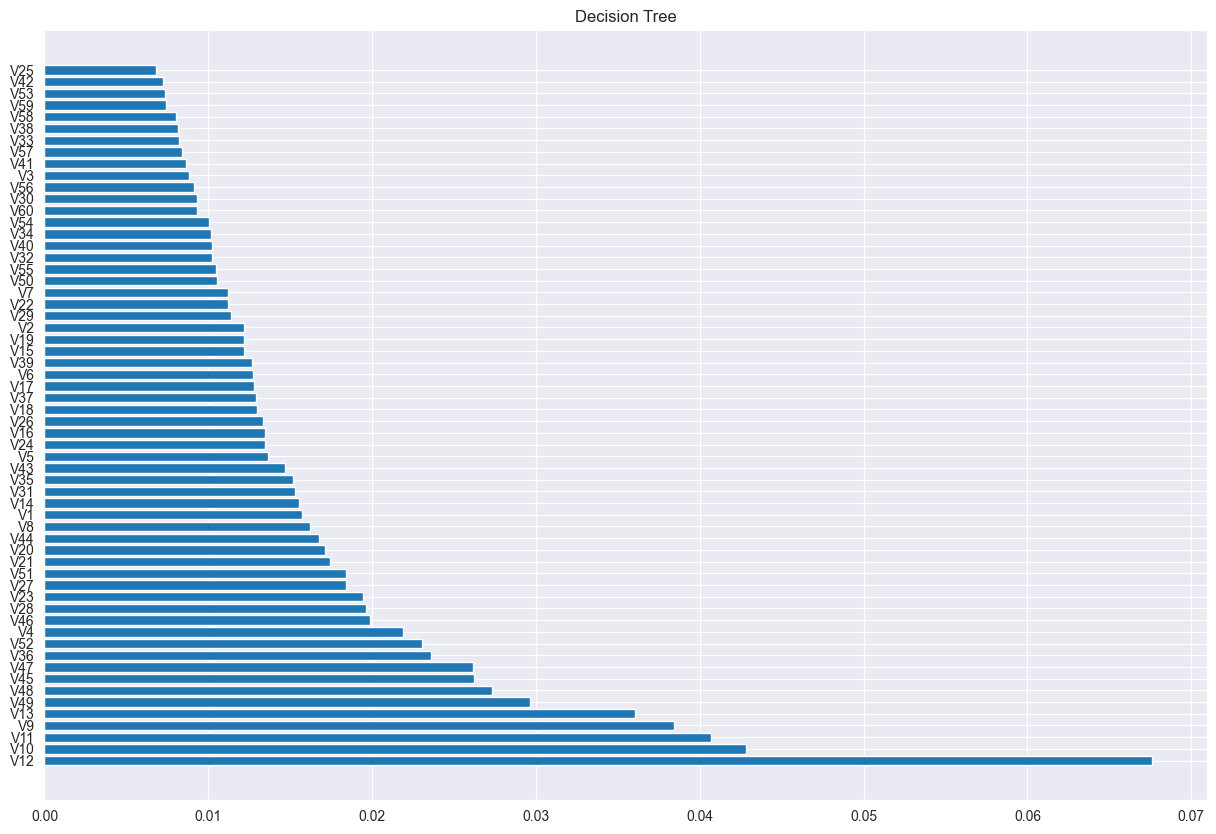

In [24]:
dtc = RandomForestClassifier(random_state=25, max_features=5)
dtc.fit(X,y)
df_imp = pd.DataFrame({'features':list(X.columns), 'importance':dtc.feature_importances_})
df_imp.sort_values('importance', ascending=False, inplace=True)
plt.figure(figsize=(15,10))
plt.barh(df_imp['features'], df_imp['importance'])
plt.title('Decision Tree')
plt.show